# 02_build_modeling_table

Zgradi **finalni clean modeling table** za slovenski nepremičninski projekt (ETN 2021–2025), s fokusom na:

- **simple apartment sales**
- **1 posel = 1 stanovanje**
- **brez zemljišč**
- **target = `log_price_per_m2`**
- `TRZNOST_POSLA` ostane kot **feature** (`trznost_group`)

Ta notebook je mišljen kot naslednji korak po `01_inspect_etn_2021_2025.ipynb`.


In [ ]:
# Če kaj manjka, odkomentiraj:
# !pip install pandas pyarrow matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
import json
import re

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)


## 1) (Opcijsko) mount Google Drive

To poženi samo v Colabu, če bereš datoteke iz Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
from pathlib import Path
DATA_DIR = Path("/content/gdrive/MyDrive/etn_2021_2025")

## 2) Nastavitve

Spodaj nastavi mapo, kjer so CSV-ji za leta 2021–2025.


In [ ]:
# Primeri:
# DATA_DIR = Path("/content")
# DATA_DIR = Path("/content/drive/MyDrive/etn_2021_2025")
# DATA_DIR = Path.home() / "Downloads" / "etn_2021_2025"

DATA_DIR = Path("/content/gdrive/MyDrive/etn_2021_2025")
OUT_DIR = DATA_DIR / "processed_outputs"
YEARS = [2021, 2022, 2023, 2024, 2025]


# Glavna odločitev za v1
ONLY_MARKET_SALES = True          # VRSTA_KUPOPRODAJNEGA_POSLA == 1
ONLY_BASIC_ACT = True             # VRSTA_AKTA == 1
REQUIRE_NO_LAND = True            # n_parcel == 0
REQUIRE_ONE_BUILDING_UNIT = True  # n_deli == 1
REQUIRE_APARTMENT = True          # VRSTA_DELA_STAVBE vsebuje "stanovanje"
REQUIRE_POSITIVE_PRICE = True
REQUIRE_VALID_AREA = True
REQUIRE_VALID_BUILD_YEAR = True
REQUIRE_VALID_PROPERTY_AGE = True
REQUIRE_FULL_SHARE = False        # če želiš še strožji rez, daj True

# Grobi filtri
MIN_AREA = 15
MAX_AREA = 250
MIN_PRICE_PER_M2 = 300
MAX_PRICE_PER_M2 = 12000
MIN_BUILD_YEAR = 1800
MAX_PROPERTY_AGE = 200

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR =", DATA_DIR)
print("exists   =", DATA_DIR.exists())
print("OUT_DIR  =", OUT_DIR)


DATA_DIR = /content/gdrive/MyDrive/etn_2021_2025
exists   = True
OUT_DIR  = /content/gdrive/MyDrive/etn_2021_2025/processed_outputs


In [ ]:
from pathlib import Path

print("DATA_DIR exists:", DATA_DIR.exists())
print("DATA_DIR is_dir:", DATA_DIR.is_dir())

print("\n--- direct children ---")
for p in sorted(DATA_DIR.iterdir()):
    print(p.name)

print("\n--- csv via rglob ---")
hits = sorted(DATA_DIR.rglob("*.csv"))
print("n csv:", len(hits))
for p in hits[:50]:
    print(p)

DATA_DIR exists: True
DATA_DIR is_dir: True

--- direct children ---
ETN_SLO_2021_KPP_KPP_DELISTAVB_20260222.csv
ETN_SLO_2021_KPP_KPP_POSLI_20260222.csv
ETN_SLO_2021_KPP_KPP_ZEMLJISCA_20260222.csv
ETN_SLO_2021_KPP_sifranti_20260222.csv
ETN_SLO_2022_KPP_KPP_DELISTAVB_20260222.csv
ETN_SLO_2022_KPP_KPP_POSLI_20260222.csv
ETN_SLO_2022_KPP_KPP_ZEMLJISCA_20260222.csv
ETN_SLO_2022_KPP_sifranti_20260222.csv
ETN_SLO_2023_KPP_KPP_DELISTAVB_20260222.csv
ETN_SLO_2023_KPP_KPP_POSLI_20260222.csv
ETN_SLO_2023_KPP_KPP_ZEMLJISCA_20260222.csv
ETN_SLO_2023_KPP_sifranti_20260222.csv
ETN_SLO_2024_KPP_KPP_DELISTAVB_20260222.csv
ETN_SLO_2024_KPP_KPP_POSLI_20260222.csv
ETN_SLO_2024_KPP_KPP_ZEMLJISCA_20260222.csv
ETN_SLO_2024_KPP_sifranti_20260222.csv
ETN_SLO_2025_KPP_KPP_DELISTAVB_20260222.csv
ETN_SLO_2025_KPP_KPP_POSLI_20260222.csv
ETN_SLO_2025_KPP_KPP_ZEMLJISCA_20260222.csv
ETN_SLO_2025_KPP_sifranti_20260222.csv
processed_outputs

--- csv via rglob ---
n csv: 21
/content/gdrive/MyDrive/etn_2021_2025/ETN_SLO

## 3) Poišči datoteke

In [ ]:
# Če so v mapi ZIP-i, jih po potrebi razširi
zip_files = sorted(DATA_DIR.rglob("ETN_SLO_*_KPP_*.zip"))
print("Najdeni ZIP-i:", len(zip_files))

PATTERNS = {
    "posli": [
        "ETN_SLO_{year}_KPP_KPP_POSLI_*.csv",
        "ETN_SLO_{year}_KPP_POSLI_*.csv",
    ],
    "delistavb": [
        "ETN_SLO_{year}_KPP_KPP_DELISTAVB_*.csv",
        "ETN_SLO_{year}_KPP_DELISTAVB_*.csv",
    ],
    "zemljisca": [
        "ETN_SLO_{year}_KPP_ZEMLJISCA_*.csv",
        "ETN_SLO_{year}_KPP_KPP_ZEMLJISCA_*.csv",
    ],
    "sifranti": [
        "ETN_SLO_{year}_KPP_sifranti_*.csv",
    ],
}

def find_first_any(patterns):
    for pattern in patterns:
        hits = sorted(DATA_DIR.rglob(pattern))
        if hits:
            return hits[0]
    return None

FILE_INDEX = {}
for year in YEARS:
    FILE_INDEX[year] = {
        kind: find_first_any([p.format(year=year) for p in pats])
        for kind, pats in PATTERNS.items()
    }

for year, files in FILE_INDEX.items():
    print(f"\n===== {year} =====")
    for kind, path in files.items():
        print(f"{kind:10s} -> {path}")

missing_years = {}
for year, files in FILE_INDEX.items():
    missing = [k for k, v in files.items() if v is None]
    if missing:
        missing_years[year] = missing

if missing_years:
    print("\nPOZOR: manjkajoče datoteke po letih:")
    print(missing_years)
else:
    print("\nVse datoteke so najdene.")

Najdeni ZIP-i: 0

===== 2021 =====
posli      -> /content/gdrive/MyDrive/etn_2021_2025/ETN_SLO_2021_KPP_KPP_POSLI_20260222.csv
delistavb  -> /content/gdrive/MyDrive/etn_2021_2025/ETN_SLO_2021_KPP_KPP_DELISTAVB_20260222.csv
zemljisca  -> /content/gdrive/MyDrive/etn_2021_2025/ETN_SLO_2021_KPP_KPP_ZEMLJISCA_20260222.csv
sifranti   -> /content/gdrive/MyDrive/etn_2021_2025/ETN_SLO_2021_KPP_sifranti_20260222.csv

===== 2022 =====
posli      -> /content/gdrive/MyDrive/etn_2021_2025/ETN_SLO_2022_KPP_KPP_POSLI_20260222.csv
delistavb  -> /content/gdrive/MyDrive/etn_2021_2025/ETN_SLO_2022_KPP_KPP_DELISTAVB_20260222.csv
zemljisca  -> /content/gdrive/MyDrive/etn_2021_2025/ETN_SLO_2022_KPP_KPP_ZEMLJISCA_20260222.csv
sifranti   -> /content/gdrive/MyDrive/etn_2021_2025/ETN_SLO_2022_KPP_sifranti_20260222.csv

===== 2023 =====
posli      -> /content/gdrive/MyDrive/etn_2021_2025/ETN_SLO_2023_KPP_KPP_POSLI_20260222.csv
delistavb  -> /content/gdrive/MyDrive/etn_2021_2025/ETN_SLO_2023_KPP_KPP_DELISTAVB_2026

## 4) Helper funkcije

In [ ]:
def load_csv(path: Path, parse_dates=None):
    df = pd.read_csv(path)
    if parse_dates:
        for col in parse_dates:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], format="%d.%m.%Y", errors="coerce")
    return df

def make_decoder(sifranti_df: pd.DataFrame, sifrant_name: str):
    sub = sifranti_df[sifranti_df["SIFRANT"].eq(sifrant_name)].copy()
    sub = sub.dropna(subset=["NUMERICNA_VREDNOST", "OPIS"])
    return dict(zip(sub["NUMERICNA_VREDNOST"], sub["OPIS"]))

def choose_area(row):
    # vrstni red je nameren: najprej prodane površine, potem fallbacki
    candidates = [
        "PRODANA_POVRSINA_DELA_STAVBE",
        "PRODANA_UPORABNA_POVRSINA_DELA_STAVBE",
        "PRODANA_POVRSINA",
        "UPORABNA_POVRSINA",
        "POVRSINA_DELA_STAVBE",
    ]
    for col in candidates:
        if col in row.index:
            val = row[col]
            if pd.notna(val) and val > 0:
                return val
    return np.nan

def area_source(row):
    candidates = [
        "PRODANA_POVRSINA_DELA_STAVBE",
        "PRODANA_UPORABNA_POVRSINA_DELA_STAVBE",
        "PRODANA_POVRSINA",
        "UPORABNA_POVRSINA",
        "POVRSINA_DELA_STAVBE",
    ]
    for col in candidates:
        if col in row.index:
            val = row[col]
            if pd.notna(val) and val > 0:
                return col
    return np.nan

def normalize_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x

def to_binary_yes_no(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x in {"da", "yes", "y", "1", "true"}:
        return 1
    if x in {"ne", "no", "n", "0", "false"}:
        return 0
    return np.nan

def simplify_trznost(x):
    x = str(x).strip().lower()

    if "neustrezni podatki" in x:
        return "market_inadequate"
    elif "tržen posel" in x or "trzen posel" in x:
        return "market"
    elif "v preverjanju" in x:
        return "under_review"
    elif "drug posel" in x:
        return "other"
    elif "neopredeljen" in x:
        return "undefined"
    else:
        return "unknown"

def value_counts_with_share(s: pd.Series, top_n=20):
    vc = s.value_counts(dropna=False).head(top_n)
    share = (vc / len(s) * 100).round(2)
    return pd.DataFrame({"count": vc, "share_%": share})

def add_missing_columns(df, cols):
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = np.nan
    return out

def log_if_positive(s):
    return np.where(s > 0, np.log(s), np.nan)


## 5) Naloži vse tabele

In [ ]:
DATE_COLS_POSLI = [
    "DATUM_UVELJAVITVE",
    "DATUM_SKLENITVE_POGODBE",
    "DATUM_ZADNJE_SPREMEMBE_POSLA",
    "DATUM_ZADNJE_UVELJAVITVE_POSLA",
    "DATUM_IZTEKA_LIZINGA",
    "DATUM_PRENEHANJA_LIZINGA",
]

posli_parts = []
deli_parts = []
zem_parts = []
sifranti_parts = []

for year in YEARS:
    files = FILE_INDEX[year]
    missing = [k for k, v in files.items() if v is None]
    if missing:
        print(f"Preskakujem {year}, ker manjkajo: {missing}")
        continue

    posli_y = load_csv(files["posli"], parse_dates=DATE_COLS_POSLI)
    deli_y = load_csv(files["delistavb"])
    zem_y = load_csv(files["zemljisca"])
    sifr_y = load_csv(files["sifranti"])

    posli_y["SOURCE_YEAR"] = year
    deli_y["SOURCE_YEAR"] = year
    zem_y["SOURCE_YEAR"] = year
    sifr_y["SOURCE_YEAR"] = year

    posli_parts.append(posli_y)
    deli_parts.append(deli_y)
    zem_parts.append(zem_y)
    sifranti_parts.append(sifr_y)

    print(f"Naloženo {year}: POSLI={posli_y.shape}, DELI={deli_y.shape}, ZEM={zem_y.shape}, SIFRANTI={sifr_y.shape}")

if not posli_parts:
    raise ValueError("Ni bilo naloženih nobenih let. Preveri DATA_DIR in poimenovanje datotek.")

posli = pd.concat(posli_parts, ignore_index=True)
deli = pd.concat(deli_parts, ignore_index=True)
zem = pd.concat(zem_parts, ignore_index=True)
sifranti = pd.concat(sifranti_parts, ignore_index=True).drop_duplicates().reset_index(drop=True)

print("\nSKUPAJ")
print("POSLI     ", posli.shape)
print("DELISTAVB ", deli.shape)
print("ZEMLJISCA ", zem.shape)
print("SIFRANTI  ", sifranti.shape)


Naloženo 2021: POSLI=(37114, 17), DELI=(33753, 40), ZEM=(68942, 17), SIFRANTI=(353, 5)
Naloženo 2022: POSLI=(37347, 17), DELI=(33396, 40), ZEM=(71691, 17), SIFRANTI=(353, 5)
Naloženo 2023: POSLI=(31257, 17), DELI=(27512, 40), ZEM=(62070, 17), SIFRANTI=(353, 5)
Naloženo 2024: POSLI=(25498, 17), DELI=(23768, 40), ZEM=(46717, 17), SIFRANTI=(353, 5)
Naloženo 2025: POSLI=(31003, 17), DELI=(27590, 40), ZEM=(60067, 17), SIFRANTI=(353, 5)

SKUPAJ
POSLI      (162219, 17)
DELISTAVB  (146019, 40)
ZEMLJISCA  (309487, 17)
SIFRANTI   (1765, 5)


## 6) Dekodiraj šifrante

In [ ]:
vrsta_posla_map = make_decoder(sifranti, "Vrsta kupoprodajnega posla")
vrsta_akta_map = make_decoder(sifranti, "Vrsta akta")
trznost_map = make_decoder(sifranti, "Tržnost posla")
vrsta_dela_map = make_decoder(sifranti, "Vrsta dela stavbe")
vrsta_zem_map = make_decoder(sifranti, "Vrsta zemljišča")

posli_d = posli.copy()
posli_d["VRSTA_KUPOPRODAJNEGA_POSLA_OPIS"] = posli_d["VRSTA_KUPOPRODAJNEGA_POSLA"].map(vrsta_posla_map)
posli_d["VRSTA_AKTA_OPIS"] = posli_d["VRSTA_AKTA"].map(vrsta_akta_map)
posli_d["TRZNOST_POSLA_OPIS"] = posli_d["TRZNOST_POSLA"].map(trznost_map)

deli_d = deli.copy()
deli_d["VRSTA_DELA_STAVBE_OPIS"] = deli_d["VRSTA_DELA_STAVBE"].map(vrsta_dela_map)

zem_d = zem.copy()
zem_d["VRSTA_ZEMLJISCA_OPIS"] = zem_d["VRSTA_ZEMLJISCA"].map(vrsta_zem_map)

display(value_counts_with_share(posli_d["VRSTA_KUPOPRODAJNEGA_POSLA_OPIS"]))
display(value_counts_with_share(posli_d["VRSTA_AKTA_OPIS"]))
display(value_counts_with_share(posli_d["TRZNOST_POSLA_OPIS"]))
display(value_counts_with_share(deli_d["VRSTA_DELA_STAVBE_OPIS"]))


,count,share_%
VRSTA_KUPOPRODAJNEGA_POSLA_OPIS,,
Prodaja nepremičnin na prostem trgu,153519,94.64
"Prodaja nepremicnin na javni dražbi ali druga oblika javne prodaje v izvršilnem postopku, prisilni poravnavi, stečaju ali stečajnem postopku",3579,2.21
Prodaja nepremičnin na prostovoljni javni dražbi ali druga oblika prostovoljne javne prodaje,3498,2.16
"Prodaja nepremičnin družinskim članom, med povezanimi fizičnimi in pravnimi osebami ali med povezanimi pravnimi osebami",1566,0.97
Finančni najem (lizing),57,0.04


,count,share_%
VRSTA_AKTA_OPIS,,
Osnovna pogodba,162219,100.0


,count,share_%
TRZNOST_POSLA_OPIS,,
Tržen posel – neustrezni podatki,83434,51.43
V preverjanju,26722,16.47
Drug posel,24259,14.95
Tržen posel,19343,11.92
Neopredeljen posel,8449,5.21
NaN,12,0.01


,count,share_%
VRSTA_DELA_STAVBE_OPIS,,
Stanovanje,46982,32.18
Stanovanjska hiša,30461,20.86
Kmetijski objekt,20812,14.25
Tehnični ali pomožni prostori,11622,7.96
Garaža,10868,7.44
Parkirni prostor,9859,6.75
Drugo,4076,2.79
Pisarniški prostori,3347,2.29
Trgovski ali storitveni lokal,2364,1.62


## 7) Pripravi relacijske agregate

In [ ]:
deli_per_posel = deli_d.groupby("ID_POSLA").size().rename("n_deli").reset_index()
zem_per_posel = zem_d.groupby("ID_POSLA").size().rename("n_parcel").reset_index()

base = posli_d.merge(deli_per_posel, on="ID_POSLA", how="left").merge(zem_per_posel, on="ID_POSLA", how="left")
base["n_deli"] = base["n_deli"].fillna(0).astype(int)
base["n_parcel"] = base["n_parcel"].fillna(0).astype(int)

print(base[["n_deli", "n_parcel"]].describe())


              n_deli       n_parcel
count  162219.000000  162219.000000
mean        0.900135       1.907834
std         1.700715       5.608324
min         0.000000       0.000000
25%         0.000000       0.000000
50%         1.000000       1.000000
75%         1.000000       2.000000
max       169.000000     573.000000


## 8) Zgradi `simple apartment sales` kandidat

In [ ]:
# samo posli z natanko enim delom stavbe in brez zemljišč
simple_ids = set(base["ID_POSLA"])

if REQUIRE_ONE_BUILDING_UNIT:
    simple_ids &= set(base.loc[base["n_deli"].eq(1), "ID_POSLA"])

if REQUIRE_NO_LAND:
    simple_ids &= set(base.loc[base["n_parcel"].eq(0), "ID_POSLA"])

deli_simple = deli_d[deli_d["ID_POSLA"].isin(simple_ids)].copy()

if REQUIRE_APARTMENT:
    mask_apartment = deli_simple["VRSTA_DELA_STAVBE_OPIS"].astype(str).str.contains("stanovanje", case=False, na=False)
    deli_simple = deli_simple[mask_apartment].copy()

# Pripravi nabor stolpcev, tudi če jih v kakšnem letu ni
required_deli_cols = [
    "ID_POSLA", "SIFRA_KO", "IME_KO", "OBCINA", "STEVILKA_STAVBE", "STEVILKA_DELA_STAVBE",
    "NASELJE", "ULICA", "HISNA_STEVILKA", "DODATEK_HS", "VRSTA_DELA_STAVBE", "VRSTA_DELA_STAVBE_OPIS",
    "LETO_IZGRADNJE_DELA_STAVBE", "STAVBA_JE_DOKONCANA", "GRADBENA_FAZA", "NOVOGRADNJA",
    "PRODANA_POVRSINA", "PRODANI_DELEZ_DELA_STAVBE", "PRODANA_POVRSINA_DELA_STAVBE",
    "PRODANA_UPORABNA_POVRSINA_DELA_STAVBE", "NADSTROPJE_DELA_STAVBE",
    "STEVILO_ZUNANJIH_PARKIRNIH_MEST", "ATRIJ", "POVRSINA_ATRIJA", "DEJANSKA_RABA_DELA_STAVBE",
    "LEGA_DELA_STAVBE_V_STAVBI", "STEVILO_SOB", "POVRSINA_DELA_STAVBE", "UPORABNA_POVRSINA",
    "PROSTORI_DELA_STAVBE", "POGODBENA_CENA_DELA_STAVBE", "E_CENTROID", "N_CENTROID", "SOURCE_YEAR"
]
required_base_cols = [
    "ID_POSLA", "DATUM_SKLENITVE_POGODBE", "POGODBENA_CENA_ODSKODNINA",
    "VRSTA_KUPOPRODAJNEGA_POSLA", "VRSTA_KUPOPRODAJNEGA_POSLA_OPIS",
    "VRSTA_AKTA", "VRSTA_AKTA_OPIS",
    "TRZNOST_POSLA", "TRZNOST_POSLA_OPIS",
    "LETO", "SOURCE_YEAR", "n_deli", "n_parcel", "VKLJUCENOST_DDV"
]

deli_simple = add_missing_columns(deli_simple, required_deli_cols)
base_subset = add_missing_columns(base, required_base_cols)

df = deli_simple.merge(
    base_subset[required_base_cols],
    on="ID_POSLA",
    how="left",
    suffixes=("", "_POSLI")
)

print("Po začetnem merge-u:", df.shape)
display(df.head(3))


Po začetnem merge-u: (28008, 54)


,ID_POSLA,SIFRA_KO,IME_KO,OBCINA,STEVILKA_STAVBE,STEVILKA_DELA_STAVBE,PARCELNA_STEVILKA_ZA_GEOLOKACIJO,INTERNA_OZNAKA_DELA_STAVBE,EVIDENTIRANOST_DELA_STAVBE,NASELJE,ULICA,HISNA_STEVILKA,DODATEK_HS,STEVILKA_STANOVANJA_ALI_POSLOVNEGA_PROSTORA,VRSTA_DELA_STAVBE,LETO_IZGRADNJE_DELA_STAVBE,STAVBA_JE_DOKONCANA,GRADBENA_FAZA,NOVOGRADNJA,PRODANA_POVRSINA,PRODANI_DELEZ_DELA_STAVBE,PRODANA_POVRSINA_DELA_STAVBE,PRODANA_UPORABNA_POVRSINA_DELA_STAVBE,NADSTROPJE_DELA_STAVBE,STEVILO_ZUNANJIH_PARKIRNIH_MEST,ATRIJ,POVRSINA_ATRIJA,OPOMBE_O_NEPREMICNINI,DEJANSKA_RABA_DELA_STAVBE,LEGA_DELA_STAVBE_V_STAVBI,STEVILO_SOB,POVRSINA_DELA_STAVBE,UPORABNA_POVRSINA,PROSTORI_DELA_STAVBE,POGODBENA_CENA_DELA_STAVBE,STOPNJA_DDV_DELA_STAVBE,E_CENTROID,N_CENTROID,LETO,SOURCE_YEAR,VRSTA_DELA_STAVBE_OPIS,DATUM_SKLENITVE_POGODBE,POGODBENA_CENA_ODSKODNINA,VRSTA_KUPOPRODAJNEGA_POSLA,VRSTA_KUPOPRODAJNEGA_POSLA_OPIS,VRSTA_AKTA,VRSTA_AKTA_OPIS,TRZNOST_POSLA,TRZNOST_POSLA_OPIS,LETO_POSLI,SOURCE_YEAR_POSLI,n_deli,n_parcel,VKLJUCENOST_DDV
0,525820,1908,PODGORJE,KAMNIK,614.0,12.0,NaN,NaN,1,KAMNIK,BAKOVNIK,5.0,D,12.0,2,1965,1,NaN,NaN,30.0,1/1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,nadstropje,NaN,29.9,25.5,bivalni prostor | klet,NaN,NaN,469375.55,118784.83,2021,2021,Stanovanje,2020-12-10,35000.0,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,2021,1,0,0
1,532981,657,MARIBOR GRAD,MARIBOR,1999.0,13.0,NaN,NaN,1,MARIBOR,VOŠNJAKOVA ULICA,25.0,NaN,13.0,2,1950,1,NaN,NaN,57.0,1/1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,nadstropje,NaN,56.7,45.9,bivalni prostor,NaN,NaN,550055.31,157775.43,2021,2021,Stanovanje,2021-02-24,73000.0,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,2021,1,0,0
2,555215,659,TABOR,MARIBOR,1559.0,10.0,NaN,NaN,1,MARIBOR,PLEČNIKOVA ULICA,3.0,NaN,10.0,2,1971,1,NaN,NaN,65.0,1/1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,nadstropje,NaN,64.8,57.8,"bivalni prostor | klet | odprta terasa, balkon, loža",NaN,NaN,549707.36,156744.89,2021,2021,Stanovanje,2021-08-13,117000.0,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,2021,1,0,0


## 9) Osnovni filtri

In [ ]:
# 1) cena
if REQUIRE_POSITIVE_PRICE:
    df = df[df["POGODBENA_CENA_ODSKODNINA"].notna() & (df["POGODBENA_CENA_ODSKODNINA"] > 0)].copy()

# 2) vrsta posla
if ONLY_MARKET_SALES:
    df = df[df["VRSTA_KUPOPRODAJNEGA_POSLA"].eq(1)].copy()

# 3) vrsta akta
if ONLY_BASIC_ACT:
    df = df[df["VRSTA_AKTA"].eq(1)].copy()

# 4) full share (opcijsko)
if REQUIRE_FULL_SHARE and "PRODANI_DELEZ_DELA_STAVBE" in df.columns:
    df = df[df["PRODANI_DELEZ_DELA_STAVBE"].between(0.99, 1.01, inclusive="both")].copy()

print("Po osnovnih filtrih:", df.shape)


Po osnovnih filtrih: (27024, 54)


## 10) Feature engineering

In [ ]:
# tekst
for c in ["OBCINA", "NASELJE", "ULICA", "IME_KO", "VRSTA_DELA_STAVBE_OPIS", "TRZNOST_POSLA_OPIS"]:
    if c in df.columns:
        df[c] = df[c].apply(normalize_text)

# lokacija
df["municipality"] = df["OBCINA"]
df["settlement"] = df["NASELJE"]
df["ko_name"] = df["IME_KO"]

# datum
df["sale_date"] = pd.to_datetime(df["DATUM_SKLENITVE_POGODBE"], errors="coerce")
df["sale_year"] = df["sale_date"].dt.year
df["sale_month"] = df["sale_date"].dt.month
df["sale_quarter"] = df["sale_date"].dt.quarter

# površina
df["area_m2"] = df.apply(choose_area, axis=1)
df["area_source"] = df.apply(area_source, axis=1)

# targeti
df["price_eur"] = df["POGODBENA_CENA_ODSKODNINA"]
df["price_per_m2"] = df["price_eur"] / df["area_m2"]

# starost
df["build_year"] = pd.to_numeric(df["LETO_IZGRADNJE_DELA_STAVBE"], errors="coerce")
df["property_age"] = df["sale_year"] - df["build_year"]

# tržnost kot feature
df["trznost_group"] = df["TRZNOST_POSLA_OPIS"].apply(simplify_trznost)

# binarni / numerični signali
df["has_atrium"] = df["ATRIJ"].apply(to_binary_yes_no) if "ATRIJ" in df.columns else np.nan
df["parking_spaces"] = pd.to_numeric(df["STEVILO_ZUNANJIH_PARKIRNIH_MEST"], errors="coerce")
df["rooms"] = pd.to_numeric(df["STEVILO_SOB"], errors="coerce")
df["usable_area_m2"] = pd.to_numeric(df["UPORABNA_POVRSINA"], errors="coerce")
df["building_area_m2"] = pd.to_numeric(df["POVRSINA_DELA_STAVBE"], errors="coerce")
df["e_centroid"] = pd.to_numeric(df["E_CENTROID"], errors="coerce")
df["n_centroid"] = pd.to_numeric(df["N_CENTROID"], errors="coerce")

# log targeti
df["log_price"] = log_if_positive(df["price_eur"])
df["log_price_per_m2"] = log_if_positive(df["price_per_m2"])

print("Po feature engineeringu:", df.shape)
display(df[[
    "ID_POSLA", "municipality", "settlement", "sale_date", "price_eur", "area_m2",
    "price_per_m2", "build_year", "property_age", "trznost_group"
]].head(5))


Po feature engineeringu: (27024, 77)


,ID_POSLA,municipality,settlement,sale_date,price_eur,area_m2,price_per_m2,build_year,property_age,trznost_group
0,525820,KAMNIK,KAMNIK,2020-12-10,35000.00,30.0,1166.666667,1965,55,market_inadequate
1,532981,MARIBOR,MARIBOR,2021-02-24,73000.00,57.0,1280.701754,1950,71,market_inadequate
2,555215,MARIBOR,MARIBOR,2021-08-13,117000.00,65.0,1800.000000,1971,50,market_inadequate
3,531164,LJUBLJANA,LJUBLJANA,2021-02-26,124415.32,84.0,1481.134762,2020,1,market_inadequate
4,534026,RADOVLJICA,LESCE,2021-03-18,105000.00,98.0,1071.428571,1947,74,market_inadequate


## 11) Strožje quality filtre

In [ ]:
before_clean = len(df)

if REQUIRE_VALID_AREA:
    df = df[df["area_m2"].between(MIN_AREA, MAX_AREA, inclusive="both")].copy()
    df = df[df["price_per_m2"].between(MIN_PRICE_PER_M2, MAX_PRICE_PER_M2, inclusive="both")].copy()

if REQUIRE_VALID_BUILD_YEAR:
    df = df[df["build_year"].isna() | df["build_year"].between(MIN_BUILD_YEAR, df["sale_year"].fillna(9999), inclusive="both")].copy()

if REQUIRE_VALID_PROPERTY_AGE:
    df = df[df["property_age"].isna() | df["property_age"].between(0, MAX_PROPERTY_AGE, inclusive="both")].copy()

# še osnovni sanity checks
df = df[df["sale_date"].notna()].copy()
df = df[df["log_price_per_m2"].notna()].copy()

after_clean = len(df)
print("Pred čiščenjem:", before_clean)
print("Po čiščenju   :", after_clean)
print("Preživelo     :", round(after_clean / max(before_clean, 1) * 100, 2), "%")


Pred čiščenjem: 27024
Po čiščenju   : 25529
Preživelo     : 94.47 %


## 12) Diagnostika

In [ ]:
summary = {
    "rows": int(len(df)),
    "unique_posli": int(df["ID_POSLA"].nunique()),
    "min_sale_date": str(df["sale_date"].min()),
    "max_sale_date": str(df["sale_date"].max()),
    "n_municipalities": int(df["municipality"].nunique(dropna=True)),
    "n_settlements": int(df["settlement"].nunique(dropna=True)),
    "share_coords_%": round((df["e_centroid"].notna() & df["n_centroid"].notna()).mean() * 100, 2),
    "median_price_eur": float(df["price_eur"].median()),
    "median_area_m2": float(df["area_m2"].median()),
    "median_price_per_m2": float(df["price_per_m2"].median()),
}

display(pd.Series(summary).to_frame("value"))

print("\nTop občine:")
display(value_counts_with_share(df["municipality"], top_n=20))

print("\nTržnost group:")
display(value_counts_with_share(df["trznost_group"], top_n=20))

print("\nMissingness (%):")
display((df.isna().mean() * 100).sort_values(ascending=False).head(25).round(2).to_frame("missing_%"))

display(df[["price_eur", "area_m2", "price_per_m2", "build_year", "property_age"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)


,value
rows,25529
unique_posli,25529
min_sale_date,2007-06-19 00:00:00
max_sale_date,2025-12-30 00:00:00
n_municipalities,198
n_settlements,659
share_coords_%,99.86
median_price_eur,119000.0
median_area_m2,58.1
median_price_per_m2,2048.726467



Top občine:


,count,share_%
municipality,,
LJUBLJANA,6132,24.02
MARIBOR,3610,14.14
CELJE,1231,4.82
KRANJ,967,3.79
KOPER,726,2.84
VELENJE,635,2.49
JESENICE,487,1.91
NOVO MESTO,427,1.67
PIRAN,406,1.59



Tržnost group:


,count,share_%
trznost_group,,
market_inadequate,12400,48.57
market,6902,27.04
under_review,4368,17.11
other,1111,4.35
undefined,748,2.93



Missingness (%):


,missing_%
PRODANA_UPORABNA_POVRSINA_DELA_STAVBE,100.00
OPOMBE_O_NEPREMICNINI,100.00
parking_spaces,100.00
has_atrium,100.00
rooms,100.00
STEVILO_SOB,100.00
POGODBENA_CENA_DELA_STAVBE,100.00
STOPNJA_DDV_DELA_STAVBE,100.00
POVRSINA_ATRIJA,100.00
STEVILO_ZUNANJIH_PARKIRNIH_MEST,100.00


,count,mean,std,min,1%,5%,50%,95%,99%,max
price_eur,25529.0,132016.855858,80757.543704,5238.72,20000.000000,35000.000000,119000.000000,275000.00000,402000.000000,950000.000000
area_m2,25529.0,60.976548,25.993069,15.00,20.000000,27.000000,58.100000,105.60000,156.388000,250.000000
price_per_m2,25529.0,2261.904452,1157.597842,300.00,416.666667,726.846591,2048.726467,4408.24669,5449.750152,11677.282378
build_year,25529.0,1969.039171,30.749267,1822.00,1857.000000,1900.000000,1974.000000,2019.00000,2023.000000,2025.000000
property_age,25529.0,53.666262,30.821082,0.00,0.000000,2.000000,50.000000,122.00000,165.000000,200.000000


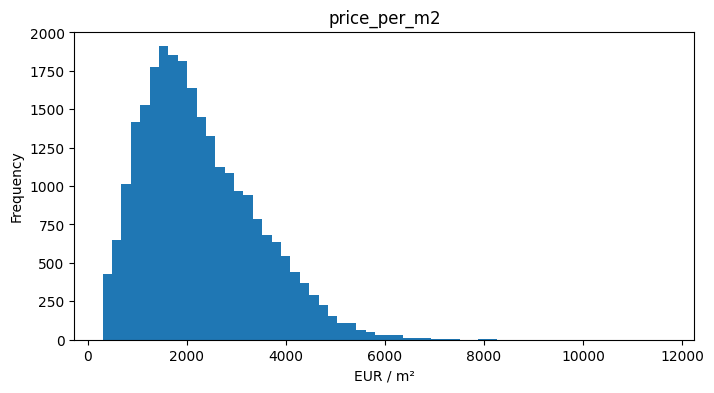

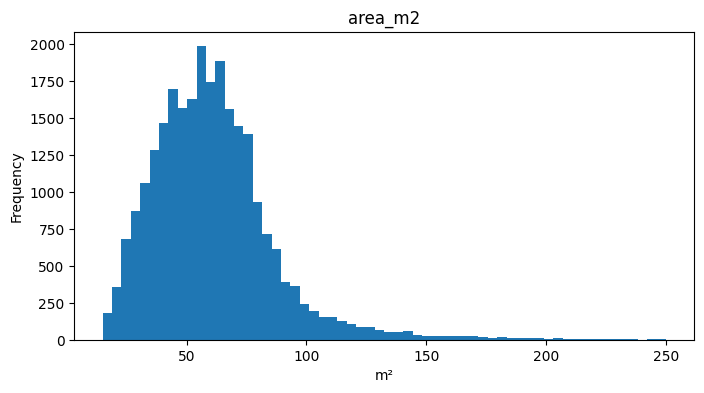

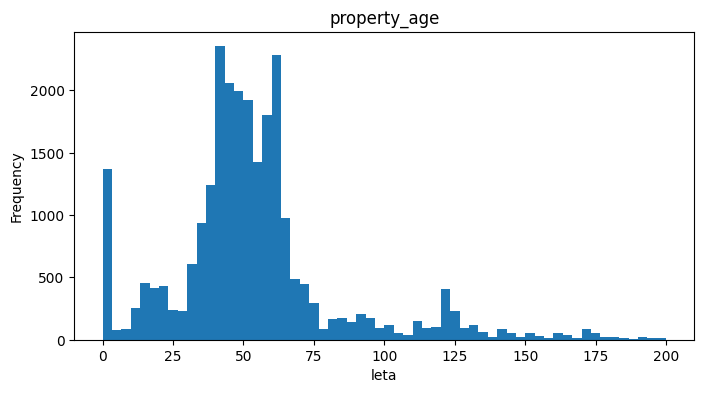

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
df["price_per_m2"].dropna().plot(kind="hist", bins=60, ax=ax)
ax.set_title("price_per_m2")
ax.set_xlabel("EUR / m²")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
df["area_m2"].dropna().plot(kind="hist", bins=60, ax=ax)
ax.set_title("area_m2")
ax.set_xlabel("m²")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
df["property_age"].dropna().plot(kind="hist", bins=60, ax=ax)
ax.set_title("property_age")
ax.set_xlabel("leta")
plt.show()


## 13) Finalni izbor featurejev za model

Tu še **ne delamo one-hot encodinga**.  
Shranjujemo čist modeling table, da ga lahko uporabiš v naslednjem notebooku za model + LIME.


In [ ]:
feature_cols = [
    # identifikacija
    "ID_POSLA",
    "sale_date",
    "sale_year",
    "sale_month",
    "sale_quarter",
    "SOURCE_YEAR",
    # targeti
    "price_eur",
    "price_per_m2",
    "log_price",
    "log_price_per_m2",
    # lokacija
    "municipality",
    "settlement",
    "ko_name",
    "SIFRA_KO",
    "e_centroid",
    "n_centroid",
    # nepremičnina
    "VRSTA_DELA_STAVBE",
    "VRSTA_DELA_STAVBE_OPIS",
    "build_year",
    "property_age",
    "area_m2",
    "area_source",
    "usable_area_m2",
    "building_area_m2",
    "rooms",
    "parking_spaces",
    "has_atrium",
    "LEGA_DELA_STAVBE_V_STAVBI",
    "NADSTROPJE_DELA_STAVBE",
    "NOVOGRADNJA",
    "STAVBA_JE_DOKONCANA",
    "GRADBENA_FAZA",
    # posel
    "VKLJUCENOST_DDV",
    "TRZNOST_POSLA",
    "TRZNOST_POSLA_OPIS",
    "trznost_group",
    "VRSTA_KUPOPRODAJNEGA_POSLA",
    "VRSTA_KUPOPRODAJNEGA_POSLA_OPIS",
    "VRSTA_AKTA",
    "VRSTA_AKTA_OPIS",
    # debug
    "n_deli",
    "n_parcel",
]

feature_cols = [c for c in feature_cols if c in df.columns]
modeling_df = df[feature_cols].copy()

print("modeling_df shape:", modeling_df.shape)
display(modeling_df.head(5))


modeling_df shape: (25529, 42)


,ID_POSLA,sale_date,sale_year,sale_month,sale_quarter,SOURCE_YEAR,price_eur,price_per_m2,log_price,log_price_per_m2,municipality,settlement,ko_name,SIFRA_KO,e_centroid,n_centroid,VRSTA_DELA_STAVBE,VRSTA_DELA_STAVBE_OPIS,build_year,property_age,area_m2,area_source,usable_area_m2,building_area_m2,rooms,parking_spaces,has_atrium,LEGA_DELA_STAVBE_V_STAVBI,NADSTROPJE_DELA_STAVBE,NOVOGRADNJA,STAVBA_JE_DOKONCANA,GRADBENA_FAZA,VKLJUCENOST_DDV,TRZNOST_POSLA,TRZNOST_POSLA_OPIS,trznost_group,VRSTA_KUPOPRODAJNEGA_POSLA,VRSTA_KUPOPRODAJNEGA_POSLA_OPIS,VRSTA_AKTA,VRSTA_AKTA_OPIS,n_deli,n_parcel
0,525820,2020-12-10,2020,12,4,2021,35000.00,1166.666667,10.463103,7.061906,KAMNIK,KAMNIK,PODGORJE,1908,469375.55,118784.83,2,Stanovanje,1965,55,30.0,PRODANA_POVRSINA,25.5,29.9,NaN,NaN,NaN,nadstropje,NaN,NaN,1,NaN,0,2.0,Tržen posel – neustrezni podatki,market_inadequate,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,1,0
1,532981,2021-02-24,2021,2,1,2021,73000.00,1280.701754,11.198215,7.155163,MARIBOR,MARIBOR,MARIBOR GRAD,657,550055.31,157775.43,2,Stanovanje,1950,71,57.0,PRODANA_POVRSINA,45.9,56.7,NaN,NaN,NaN,nadstropje,NaN,NaN,1,NaN,0,2.0,Tržen posel – neustrezni podatki,market_inadequate,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,1,0
2,555215,2021-08-13,2021,8,3,2021,117000.00,1800.000000,11.669929,7.495542,MARIBOR,MARIBOR,TABOR,659,549707.36,156744.89,2,Stanovanje,1971,50,65.0,PRODANA_POVRSINA,57.8,64.8,NaN,NaN,NaN,nadstropje,NaN,NaN,1,NaN,0,2.0,Tržen posel – neustrezni podatki,market_inadequate,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,1,0
3,531164,2021-02-26,2021,2,1,2021,124415.32,1481.134762,11.731381,7.300564,LJUBLJANA,LJUBLJANA,NOVE JARŠE,2680,464490.81,103425.15,2,Stanovanje,2020,1,84.0,PRODANA_POVRSINA,55.1,84.0,NaN,NaN,NaN,pritličje,NaN,1.0,1,NaN,1,2.0,Tržen posel – neustrezni podatki,market_inadequate,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,1,0
4,534026,2021-03-18,2021,3,1,2021,105000.00,1071.428571,11.561716,6.976748,RADOVLJICA,LESCE,HRAŠE,2155,434810.00,135946.75,2,Stanovanje,1947,74,98.0,PRODANA_POVRSINA,74.5,97.9,NaN,NaN,NaN,pritličje,NaN,NaN,1,NaN,0,2.0,Tržen posel – neustrezni podatki,market_inadequate,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,1,0


## 14) Shrani outpute

In [ ]:
parquet_path = OUT_DIR / "slovenia_apartments_modeling_v1.parquet"
csv_path = OUT_DIR / "slovenia_apartments_modeling_v1.csv"
summary_path = OUT_DIR / "slovenia_apartments_modeling_v1_summary.json"
feature_dict_path = OUT_DIR / "slovenia_apartments_modeling_v1_feature_columns.json"

modeling_df.to_parquet(parquet_path, index=False)
modeling_df.to_csv(csv_path, index=False)

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)

with open(feature_dict_path, "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

print("Saved:")
print(" -", parquet_path)
print(" -", csv_path)
print(" -", summary_path)
print(" -", feature_dict_path)


Saved:
 - /content/gdrive/MyDrive/etn_2021_2025/processed_outputs/slovenia_apartments_modeling_v1.parquet
 - /content/gdrive/MyDrive/etn_2021_2025/processed_outputs/slovenia_apartments_modeling_v1.csv
 - /content/gdrive/MyDrive/etn_2021_2025/processed_outputs/slovenia_apartments_modeling_v1_summary.json
 - /content/gdrive/MyDrive/etn_2021_2025/processed_outputs/slovenia_apartments_modeling_v1_feature_columns.json


In [ ]:
print("OUT_DIR =", OUT_DIR)
print("exists:", OUT_DIR.exists())

for p in sorted(OUT_DIR.iterdir()):
    print(p.name)

OUT_DIR = /content/gdrive/MyDrive/etn_2021_2025/processed_outputs
exists: True
slovenia_apartments_modeling_v1.csv
slovenia_apartments_modeling_v1.parquet
slovenia_apartments_modeling_v1_feature_columns.json
slovenia_apartments_modeling_v1_summary.json


## 15) Kaj sledi

Naslednji notebook naj naredi:

1. **train / validation split** po času (`sale_year`, `sale_date`)
2. izbiro featurejev za model
3. primerjavo:
   - **Model A:** brez `trznost_group`
   - **Model B:** z `trznost_group`
4. Random Forest
5. LIME razlage
6. export modela za Streamlit app

Priporočen target za v1:
- **`log_price_per_m2`**
